In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import stim
import sinter
import matplotlib.pyplot as plt
import os
from qecsim.xzzx_code.circuit import XZZX_code
import pickle
import numpy as np

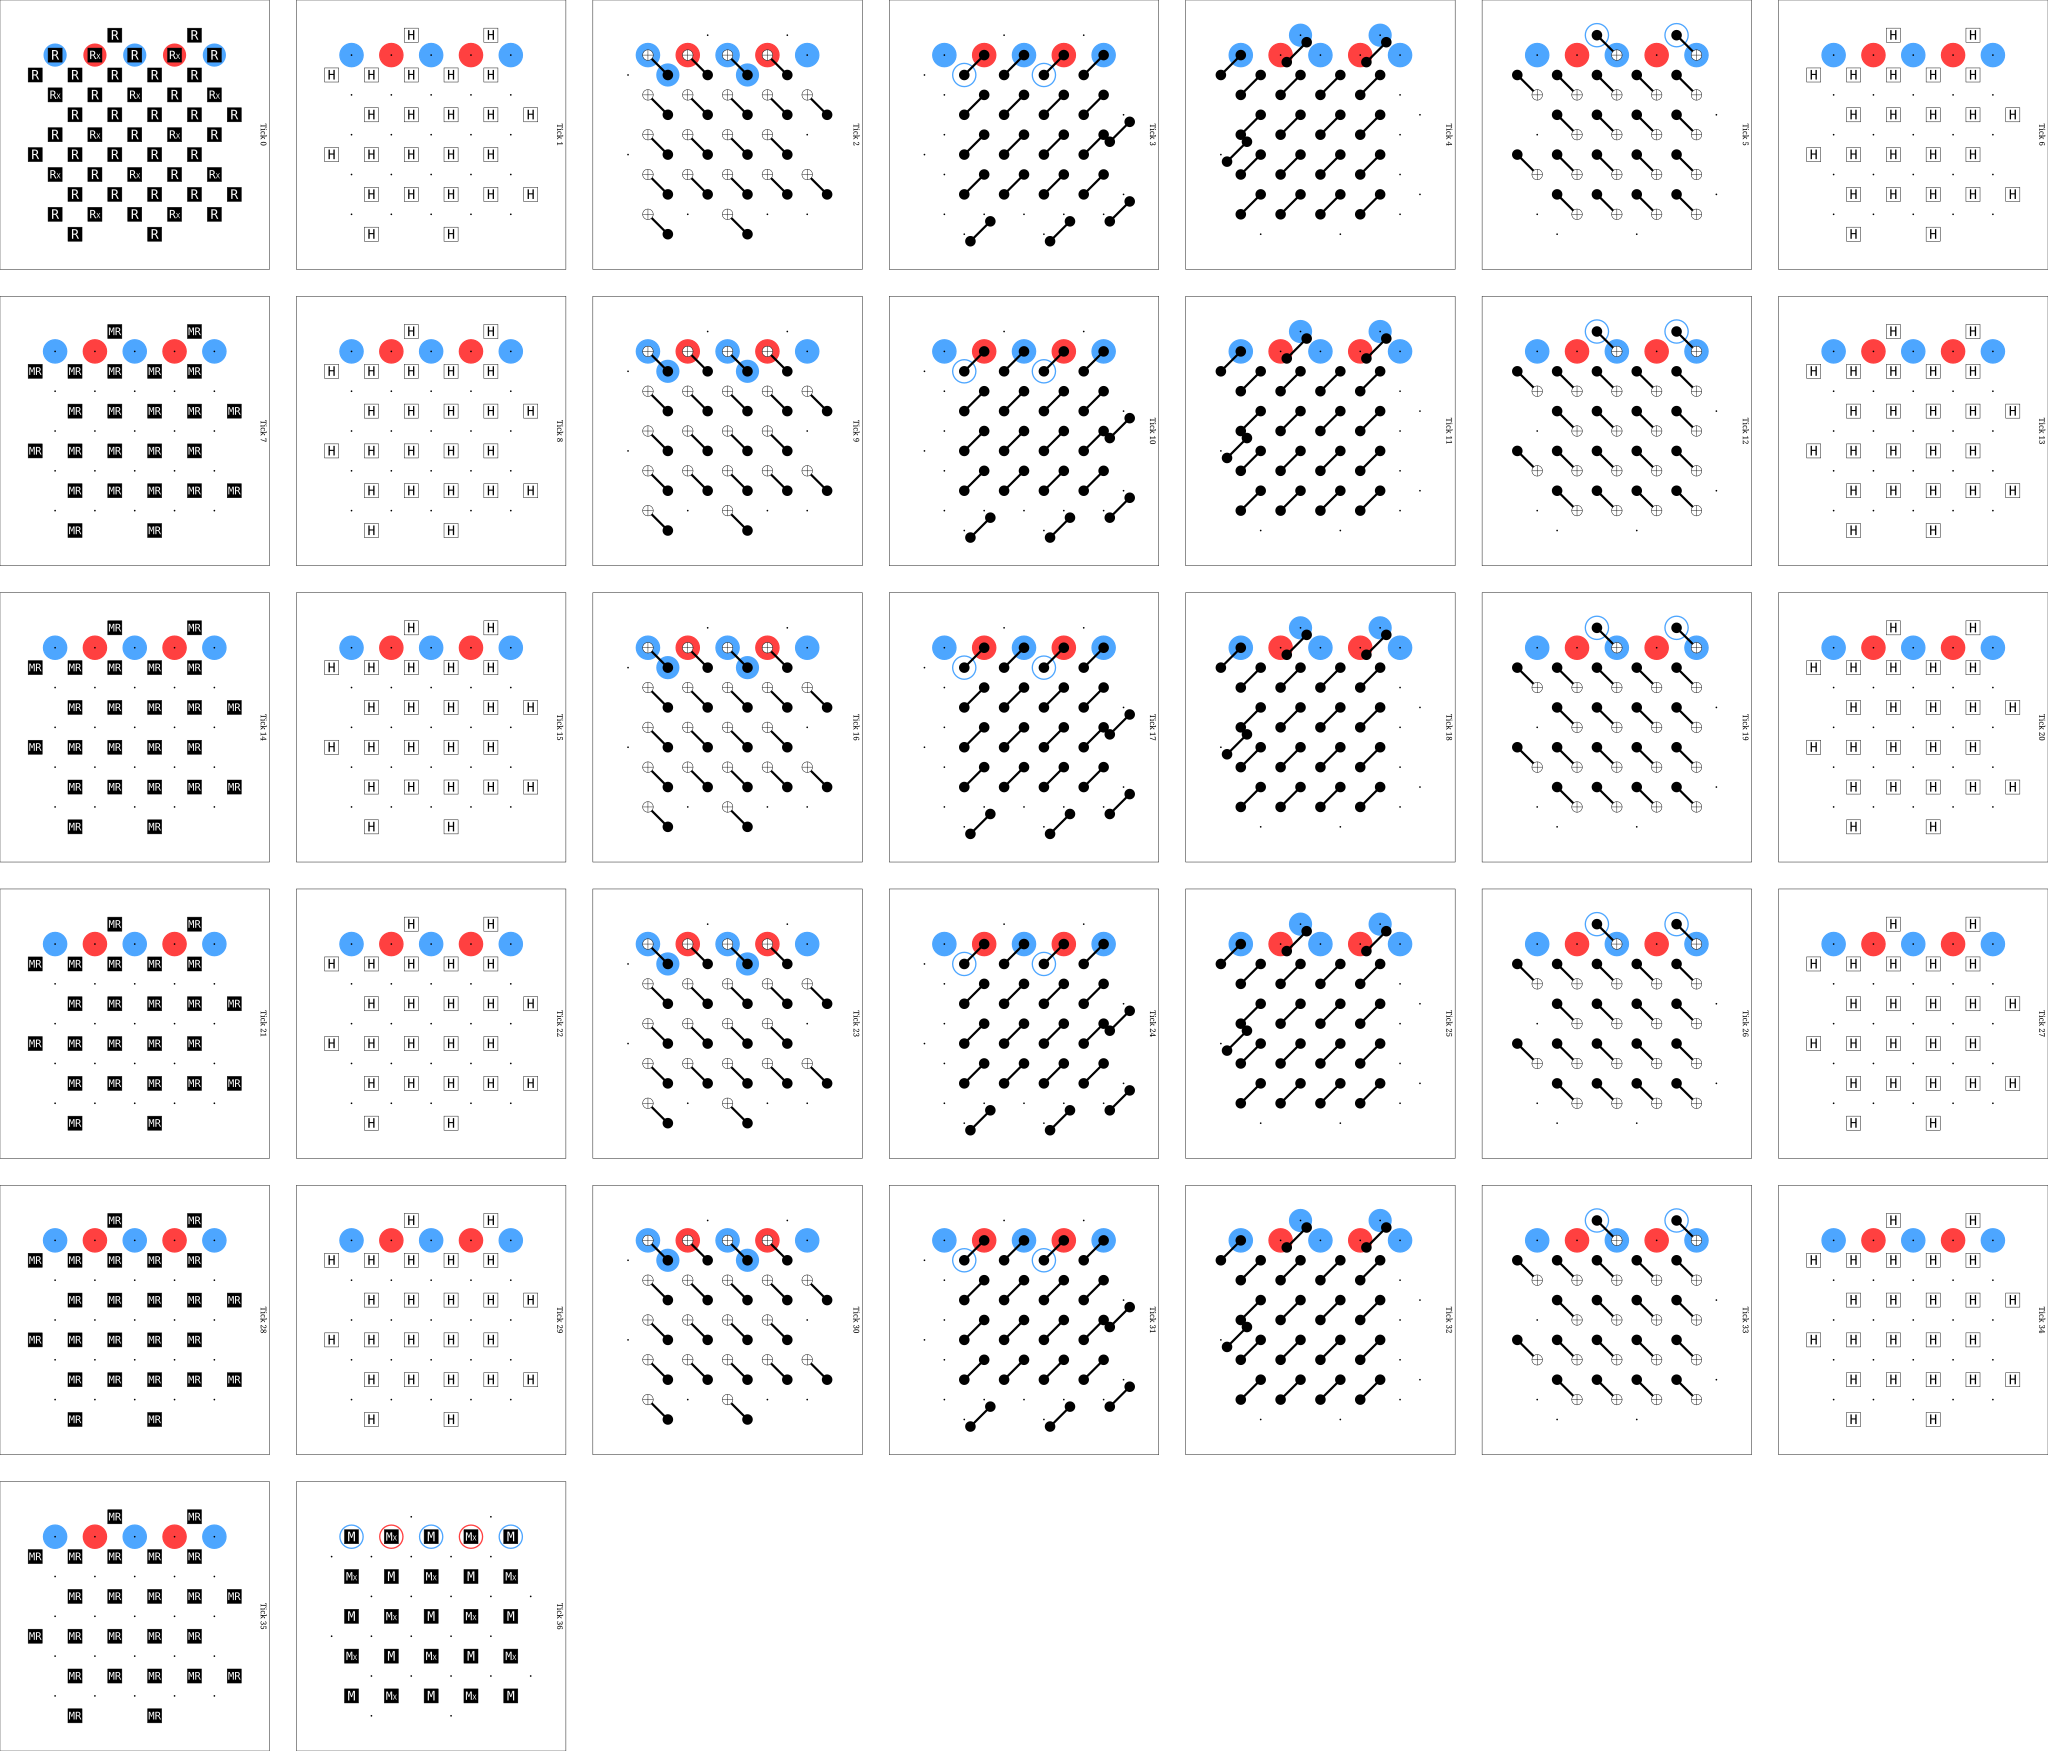

In [6]:
XZZX_code(distance = 5, rounds = 5, state_init = "Hor").diagram("detslice-with-ops-svg", filter_coords = ["L0"])

In [ ]:
task_noisy_v = [sinter.Task(
    circuit = XZZX_code(
        distance = d,
        rounds = d, 
        state_init ="Ver", 
        before_m_flip_prob = noise,
        before_round_depol = noise,
        after_c_depol_prob = noise,
        after_r_flip = noise
        ),
    json_metadata={'p': noise, 'distance' : d}
    ) 
    for noise in [0.001, 0.0015, 0.002, 0.0025, 0.005, 0.010, 0.015, 0.1]
    for d in [3, 5, 7, 9, 11, 13]
    ]

task_noisy_h = [sinter.Task(
    circuit = XZZX_code(
        distance = d, 
        rounds = d,
        state_init ="Hor", 
        before_m_flip_prob = noise,
        before_round_depol = noise,
        after_c_depol_prob = noise,
        after_r_flip = noise
        ),
    json_metadata={'p': noise, 'distance' : d}
    ) 
    for noise in [0.001, 0.0015, 0.002, 0.0025, 0.005, 0.010, 0.015, 0.1]
    for d in [3, 5, 7, 9, 11, 13]
    ]


stats_noisy_v : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=task_noisy_v,
    decoders=['pymatching'],
    max_shots=100_000_0,
    max_errors=10000,
    print_progress=True
)

stats_noisy_h : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=task_noisy_h,
    decoders=['pymatching'],
    max_shots=100_000_0,
    max_errors=10000,
    print_progress=True
)

Starting 8 workers...
48 tasks left:
  workers    decoder eta shots_left errors_left json_metadata       
        1 pymatching   ?    1000000       10000 p=0.001,distance=3  
        1 pymatching   ?    1000000       10000 p=0.001,distance=5  
        1 pymatching   ?    1000000       10000 p=0.001,distance=7  
        1 pymatching   ?    1000000       10000 p=0.001,distance=9  
        1 pymatching   ?    1000000       10000 p=0.001,distance=11 
        1 pymatching   ?    1000000       10000 p=0.001,distance=13 
        1 pymatching <1m     993583        9905 p=0.0015,distance=3 
        1 pymatching   ?    1000000       10000 p=0.0015,distance=5 
        0 pymatching ?·∞    1000000       10000 p=0.0015,distance=7 
        0 pymatching ?·∞    1000000       10000 p=0.0015,distance=9 
        0 pymatching ?·∞    1000000       10000 p=0.0015,distance=11
        0 pymatching ?·∞    1000000       10000 p=0.0015,distance=13
        0 pymatching ?·∞    1000000       10000 p=0.002,distance=3

In [9]:
#Saving Stats with pickle
with open("XZZX_full_noise_vertical.pkl", "wb") as file:
    pickle.dump(stats_noisy_v, file)

with open("XZZX_full_noise_horizontal.pkl", "wb") as file:
    pickle.dump(stats_noisy_h, file)

In [ ]:
#Loading Stats with pickle
with open("XZZX_full_noise_vertical.pkl", "rb") as file:
    stats_noisy_v = pickle.load(file)

with open("XZZX_full_noise_horizontal.pkl", "rb") as file:
    stats_noisy_h = pickle.load(file)

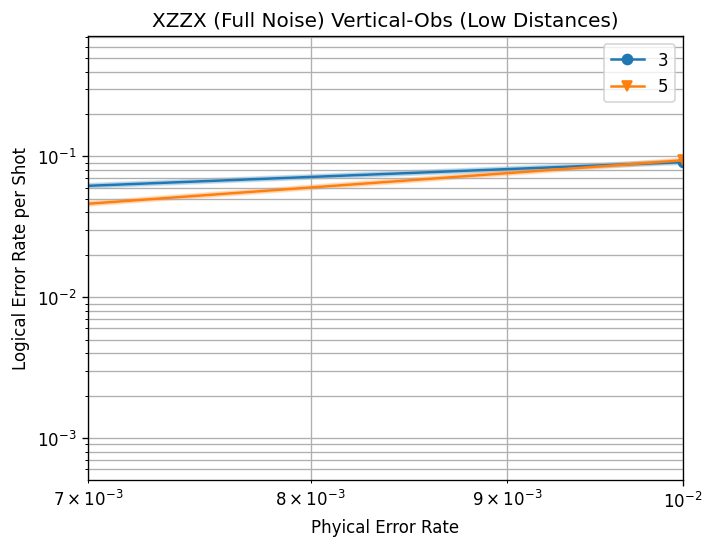

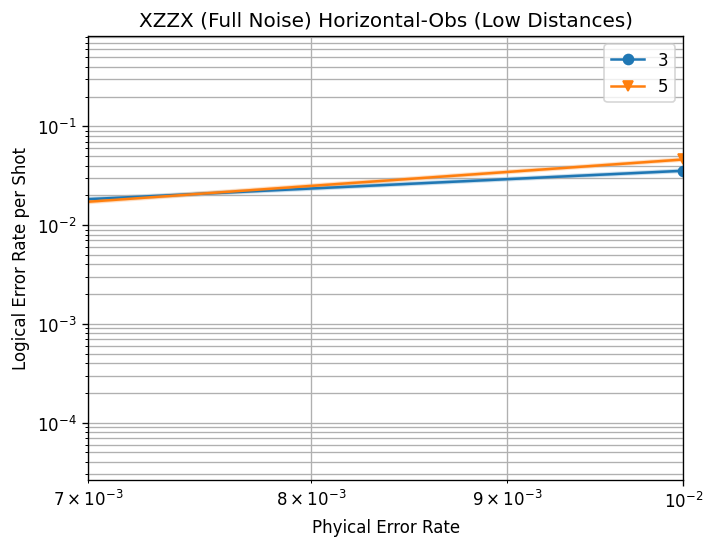

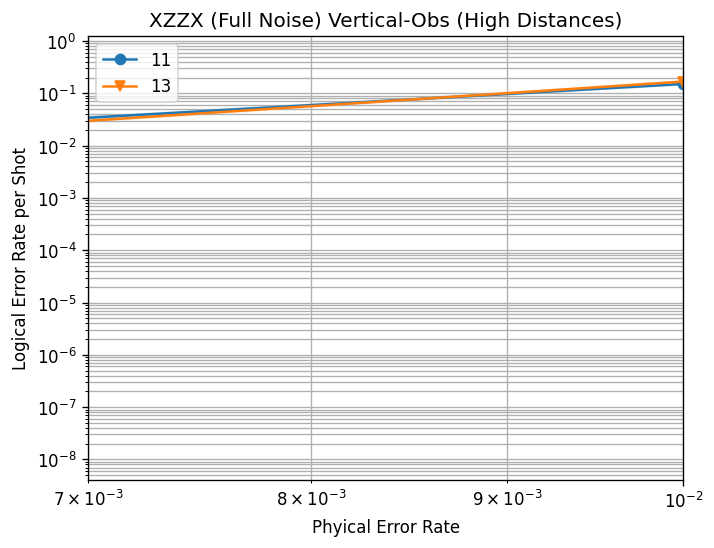

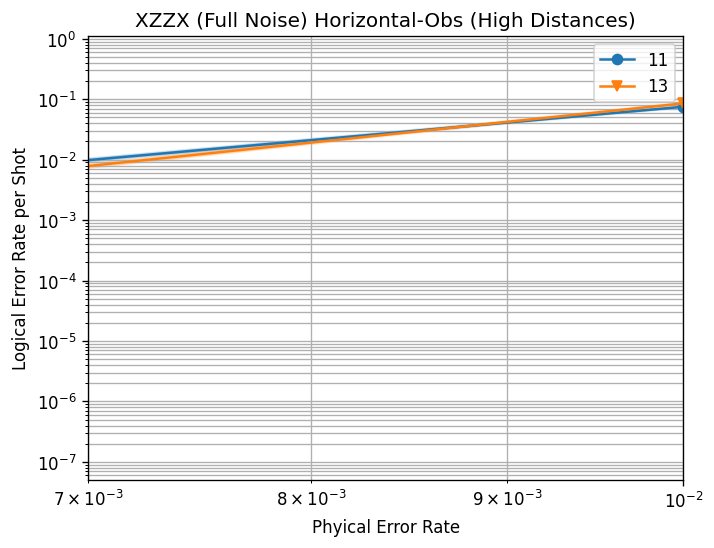

In [10]:
#################################
# Filter to low Distances only
#################################

reduced_noisy_v_ld = [i for i in stats_noisy_v if i.json_metadata["distance"] in {3,5}]
reduced_noisy_h_ld = [i for i in stats_noisy_h if i.json_metadata["distance"] in {3,5}]

######################################
# Plotting Noise (Vertical Observable)
######################################

fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=reduced_noisy_v_ld,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'])
ax.loglog()
ax.set_xlim(7e-3, 1e-2)
ax.set_title("XZZX (Full Noise) Vertical-Obs (Low Distances)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

########################################
# Plotting Noise (Horizontal Observable)
########################################

fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=reduced_noisy_h_ld,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'])
ax.loglog()
ax.set_xlim(7e-3, 1e-2)
ax.set_title("XZZX (Full Noise) Horizontal-Obs (Low Distances)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

#################################
# Filter to larger Distances only
#################################

reduced_noisy_v_hd = [i for i in stats_noisy_v if i.json_metadata["distance"] in {11,13}]
reduced_noisy_h_hd = [i for i in stats_noisy_h if i.json_metadata["distance"] in {11,13}]

######################################
# Plotting Noise (Vertical Observable)
######################################

fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=reduced_noisy_v_hd,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'])
ax.loglog()
ax.set_xlim(7e-3, 1e-2)
ax.set_title("XZZX (Full Noise) Vertical-Obs (High Distances)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

########################################
# Plotting Noise (Horizontal Observable)
########################################

fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=reduced_noisy_h_hd,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'])
ax.loglog()
ax.set_xlim(7e-3, 1e-2)
ax.set_title("XZZX (Full Noise) Horizontal-Obs (High Distances)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger